In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")

df = pd.read_csv('incident_event_log.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head(3))
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (141712, 36)

Columns:
 ['number', 'incident_state', 'active', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor', 'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at']

First 3 rows:
        number incident_state  active  reassignment_count  reopen_count  \
0  INC0000045            New    True                   0             0   
1  INC0000045       Resolved    True                   0             0   
2  INC0000045       Resolved    True                   0             0   

   sys_mod_count  made_sla    caller_id     opened_by        opened_at  ...  \
0              0      True  Caller 2403  Opened by  8  29/2/2

In [4]:
# convert date columns to datetime format
df['opened_at'] = pd.to_datetime(df['opened_at'], dayfirst=True, errors='coerce')
df['resolved_at'] = pd.to_datetime(df['resolved_at'], dayfirst=True, errors='coerce')
df['closed_at'] = pd.to_datetime(df['closed_at'], dayfirst=True, errors='coerce')
df['sys_created_at'] = pd.to_datetime(df['sys_created_at'], dayfirst=True, errors='coerce')

# replace ? with NaN so Python treats them as proper missing values
df.replace('?', np.nan, inplace=True)

# calculate resolution time in hours
df['resolution_hours'] = (df['resolved_at'] - df['opened_at']).dt.total_seconds() / 3600

# keep only resolved/closed incidents for analysis (filter out still-open ones)
df_resolved = df[df['resolved_at'].notna()].copy()

# convert made_sla to readable labels
df_resolved['sla_status'] = df_resolved['made_sla'].map({True: 'Met SLA', False: 'Breached SLA'})

print("Total incidents after cleaning:", df_resolved['number'].nunique())
print("Resolution time stats (hours):")
print(df_resolved['resolution_hours'].describe().round(2))
print("\nSLA Status counts:")
print(df_resolved['sla_status'].value_counts())
print("\nPriority breakdown:")
print(df_resolved['priority'].value_counts())
print("\nTop 10 categories:")
print(df_resolved['category'].value_counts().head(10))

Total incidents after cleaning: 23362
Resolution time stats (hours):
count    138571.00
mean        269.60
std         650.87
min           0.00
25%           4.07
50%          73.52
75%         262.18
max        8070.17
Name: resolution_hours, dtype: float64

SLA Status counts:
sla_status
Met SLA         129541
Breached SLA      9030
Name: count, dtype: int64

Priority breakdown:
priority
3 - Moderate    129511
4 - Low           3830
2 - High          2972
1 - Critical      2258
Name: count, dtype: int64

Top 10 categories:
category
Category 26    17865
Category 53    15785
Category 42    15130
Category 46    13172
Category 23     7763
Category 9      7293
Category 32     6762
Category 57     6512
Category 37     6491
Category 20     5274
Name: count, dtype: int64


Total incidents: 23,362 — this is the number of unique incidents.
Average resolution time is 269 hours — that's over 11 days!
The minimum is 0 hours 
50% of incidents take 73 hours 
The maximum is 8,070 hours
The big gap between mean (269) and median (73) tells us a small number of extremely slow incidents are dragging the average up massively — this is called a skewed distribution (Distribution tells how your data values are spread out ,Since here the mean is more and median is small which tells there are few large values)
129,541 Met SLA vs 9,030 Breached SLA
Most incidents are Priority 3 (Moderate) — 129,511 cases
Only 2,258 are Priority 1 (Critical)


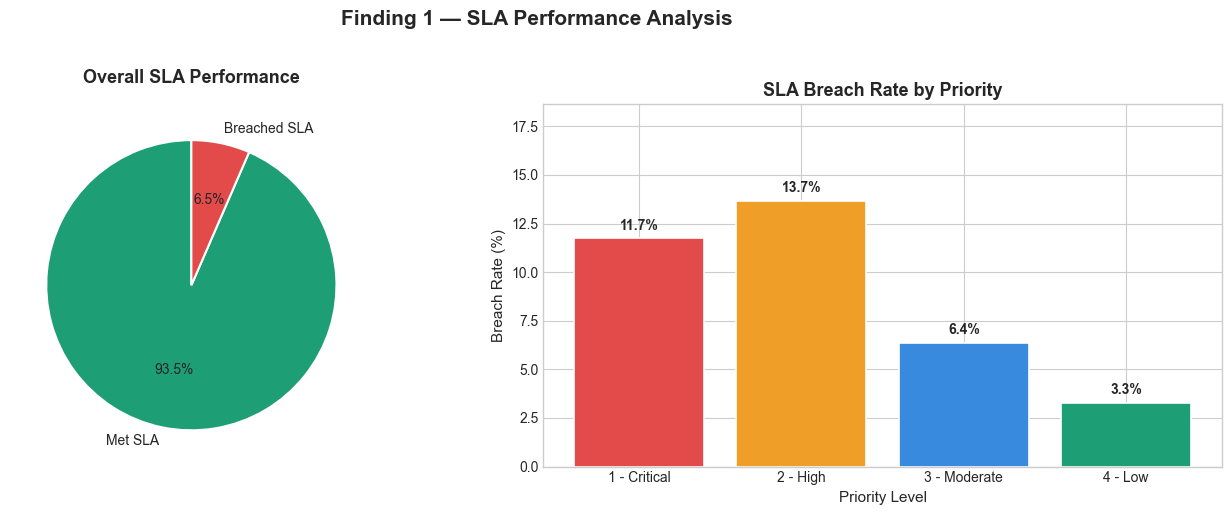


Breach rate by priority:
    priority  breach_rate
1 - Critical    11.736050
    2 - High    13.660834
3 - Moderate     6.357761
     4 - Low     3.263708


In [38]:
# ── ANALYSIS 1: Overall SLA breach rate ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — overall SLA pie chart
sla_counts = df_resolved['sla_status'].value_counts()
colors = ['#1D9E75', '#E24B4A']
axes[0].pie(
    sla_counts,
    labels=sla_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
axes[0].set_title('Overall SLA Performance', fontsize=13, fontweight='bold', pad=15)

# Chart 2 — SLA breach rate by priority
priority_sla = df_resolved.groupby('priority')['made_sla'].apply(
    lambda x: (x == False).sum() / len(x) * 100
).reset_index()
priority_sla.columns = ['priority', 'breach_rate']
priority_sla = priority_sla.sort_values('priority') #(lambda function here is to count how many false values are there and convert it into percentage)

bars = axes[1].bar(
    priority_sla['priority'],
    priority_sla['breach_rate'],
    color=['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75'],
    edgecolor='white',
    linewidth=1.2
)

for bar, val in zip(bars, priority_sla['breach_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[1].set_title('SLA Breach Rate by Priority', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Priority Level', fontsize=11)
axes[1].set_ylabel('Breach Rate (%)', fontsize=11)
axes[1].set_ylim(0, max(priority_sla['breach_rate']) + 5)

plt.suptitle('Finding 1 — SLA Performance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('finding1_sla_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBreach rate by priority:")
print(priority_sla.to_string(index=False))

priority level 2 has the highest breach rate 



In [47]:
# get top 10 categories by volume
top_categories = df_resolved['category'].value_counts().head(10).index
print(top_categories)
df_top_cat = df_resolved[df_resolved['category'].isin(top_categories)]


Index(['Category 26', 'Category 53', 'Category 42', 'Category 46',
       'Category 23', 'Category 9', 'Category 32', 'Category 57',
       'Category 37', 'Category 20'],
      dtype='str', name='category')


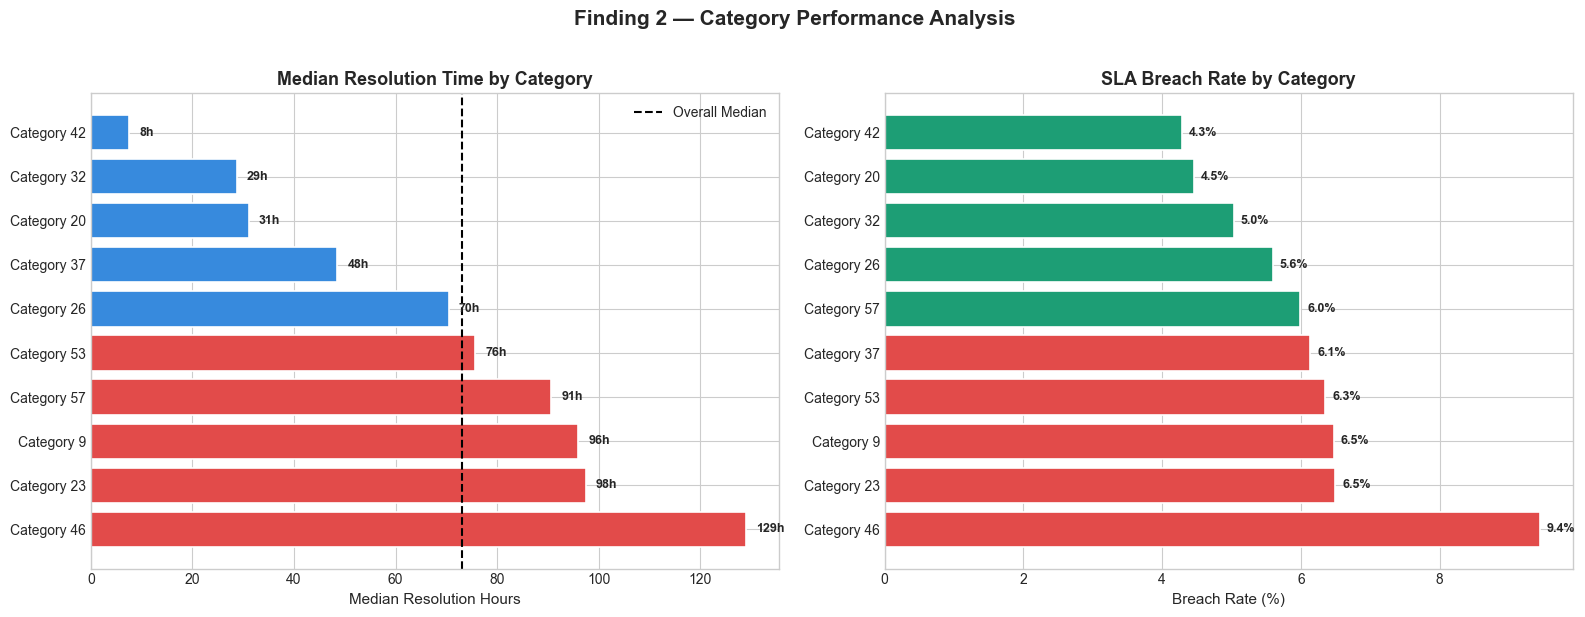


Category Summary:
   category  avg_resolution_hrs  breach_rate  total_incidents
Category 46              129.03         9.44            13172
Category 23               97.50         6.49             7763
 Category 9               96.00         6.47             7293
Category 57               90.65         5.99             6512
Category 53               75.67         6.35            15785
Category 26               70.47         5.59            17865
Category 37               48.50         6.13             6491
Category 20               31.10         4.46             5274
Category 32               28.73         5.03             6762
Category 42                7.53         4.29            15130


In [48]:
# ANALYSIS 2: Resolution time by category 

# get top 10 categories by volume
top_categories = df_resolved['category'].value_counts().head(10).index

# filter for top categories only
df_top_cat = df_resolved[df_resolved['category'].isin(top_categories)]

# calculate median resolution time and breach rate per category
cat_analysis = df_top_cat.groupby('category').agg(
    avg_resolution_hrs=('resolution_hours', 'median'),
    breach_rate=('made_sla', lambda x: (x == False).sum() / len(x) * 100),
    total_incidents=('number', 'count')
).reset_index()

cat_analysis = cat_analysis.sort_values('avg_resolution_hrs', ascending=False)

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# chart 1 — median resolution time by category
colors_cat = ['#E24B4A' if x > cat_analysis['avg_resolution_hrs'].median()
              else '#378ADD' for x in cat_analysis['avg_resolution_hrs']]

bars1 = axes[0].barh(
    cat_analysis['category'],
    cat_analysis['avg_resolution_hrs'],
    color=colors_cat,
    edgecolor='white',
    linewidth=1.2
)

axes[0].axvline(
    cat_analysis['avg_resolution_hrs'].median(),
    color='black', linestyle='--', linewidth=1.5, label='Overall Median'
)

for bar, val in zip(bars1, cat_analysis['avg_resolution_hrs']):
    axes[0].text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        f'{val:.0f}h',
        va='center', fontsize=9, fontweight='bold'
    )

axes[0].set_title('Median Resolution Time by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median Resolution Hours', fontsize=11)
axes[0].legend(fontsize=10)

# chart 2 — breach rate by category
cat_analysis_breach = cat_analysis.sort_values('breach_rate', ascending=False)

colors_breach = ['#E24B4A' if x > cat_analysis_breach['breach_rate'].mean()
                 else '#1D9E75' for x in cat_analysis_breach['breach_rate']]

bars2 = axes[1].barh(
    cat_analysis_breach['category'],
    cat_analysis_breach['breach_rate'],
    color=colors_breach,
    edgecolor='white',
    linewidth=1.2
)

for bar, val in zip(bars2, cat_analysis_breach['breach_rate']):
    axes[1].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center', fontsize=9, fontweight='bold'
    )

axes[1].set_title('SLA Breach Rate by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Breach Rate (%)', fontsize=11)

plt.suptitle('Finding 2 — Category Performance Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('finding2_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCategory Summary:")
print(cat_analysis[['category', 'avg_resolution_hrs',
                     'breach_rate', 'total_incidents']].round(2).to_string(index=False))

Category 46 emerged as the highest risk category in our analysis it had both the longest median resolution time and the highest SLA breach rate among all top 10 categories by volume. This double confirmation across two independent metrics suggests a systemic process failure specific to this category rather than random variation. I recommended a focused process review for C
ategory 46 as the single highest impact intervention available.

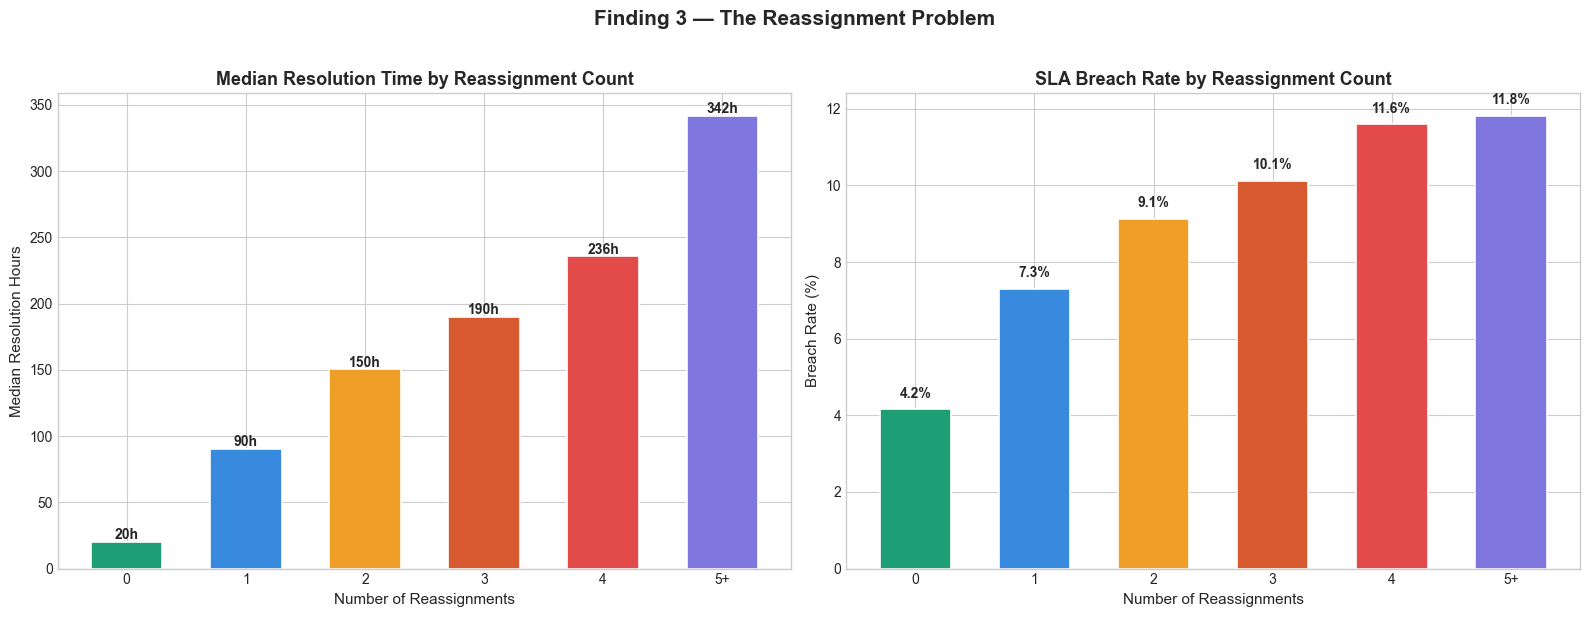


Reassignment Impact Summary:
reassignment_bucket  median_resolution_hrs  breach_rate  total_incidents
                  0                  20.23         4.16            66757
                  1                  90.40         7.30            37082
                  2                 150.50         9.13            15097
                  3                 189.92        10.12             8274
                  4                 235.67        11.60             4614
                 5+                 341.72        11.81             6747


In [49]:
# ANALYSIS 3: Reassignment impact on resolution time

# cap reassignment count at 5+ to avoid tiny sample sizes at high numbers
df_resolved['reassignment_bucket'] = df_resolved['reassignment_count'].apply(
    lambda x: '5+' if x >= 5 else str(x)
)

# define order for x axis
reassignment_order = ['0', '1', '2', '3', '4', '5+']

# calculate median resolution time and breach rate per reassignment bucket
reassign_analysis = df_resolved.groupby('reassignment_bucket').agg(
    median_resolution_hrs=('resolution_hours', 'median'),
    breach_rate=('made_sla', lambda x: (x == False).sum() / len(x) * 100),
    total_incidents=('number', 'count')
).reindex(reassignment_order).reset_index()

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# chart 1 — median resolution time by reassignment count
bars1 = axes[0].bar(
    reassign_analysis['reassignment_bucket'],
    reassign_analysis['median_resolution_hrs'],
    color=['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#E24B4A', '#7F77DD'],
    edgecolor='white',
    linewidth=1.2,
    width=0.6
)

for bar, val in zip(bars1, reassign_analysis['median_resolution_hrs']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{val:.0f}h',
        ha='center', fontsize=10, fontweight='bold'
    )

axes[0].set_title('Median Resolution Time by Reassignment Count',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reassignments', fontsize=11)
axes[0].set_ylabel('Median Resolution Hours', fontsize=11)

# chart 2 — breach rate by reassignment count
bars2 = axes[1].bar(
    reassign_analysis['reassignment_bucket'],
    reassign_analysis['breach_rate'],
    color=['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#E24B4A', '#7F77DD'],
    edgecolor='white',
    linewidth=1.2,
    width=0.6
)

for bar, val in zip(bars2, reassign_analysis['breach_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=10, fontweight='bold'
    )

axes[1].set_title('SLA Breach Rate by Reassignment Count',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reassignments', fontsize=11)
axes[1].set_ylabel('Breach Rate (%)', fontsize=11)

plt.suptitle('Finding 3 — The Reassignment Problem',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('finding3_reassignment_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nReassignment Impact Summary:")
print(reassign_analysis[['reassignment_bucket', 'median_resolution_hrs',
                          'breach_rate', 'total_incidents']].round(2).to_string(index=False))

Three killer insights hiding in this table:
Insight 1 — The first reassignment is the most damaging single step.
Going from 0 to 1 reassignment increases resolution time from 20 hours to 90 hours. That is a 4.5x jump from just one handover. No other step causes that much damage. This alone is worth an entire recommendation to management.
Insight 2 — The tipping point is 3 reassignments.
Between 0 and 3 reassignments breach rate goes from 4.2% to 10.1% — it more than doubles. After 3 reassignments the breach rate plateaus around 11-12% suggesting teams are doing damage control by that point but the damage is already done.
Insight 3 — Volume tells a story too.
66,757 incidents had zero reassignments. But 6,747 incidents needed 5+ reassignments. Those are complex incidents that nobody owns — they keep getting passed around until someone is forced to close them.

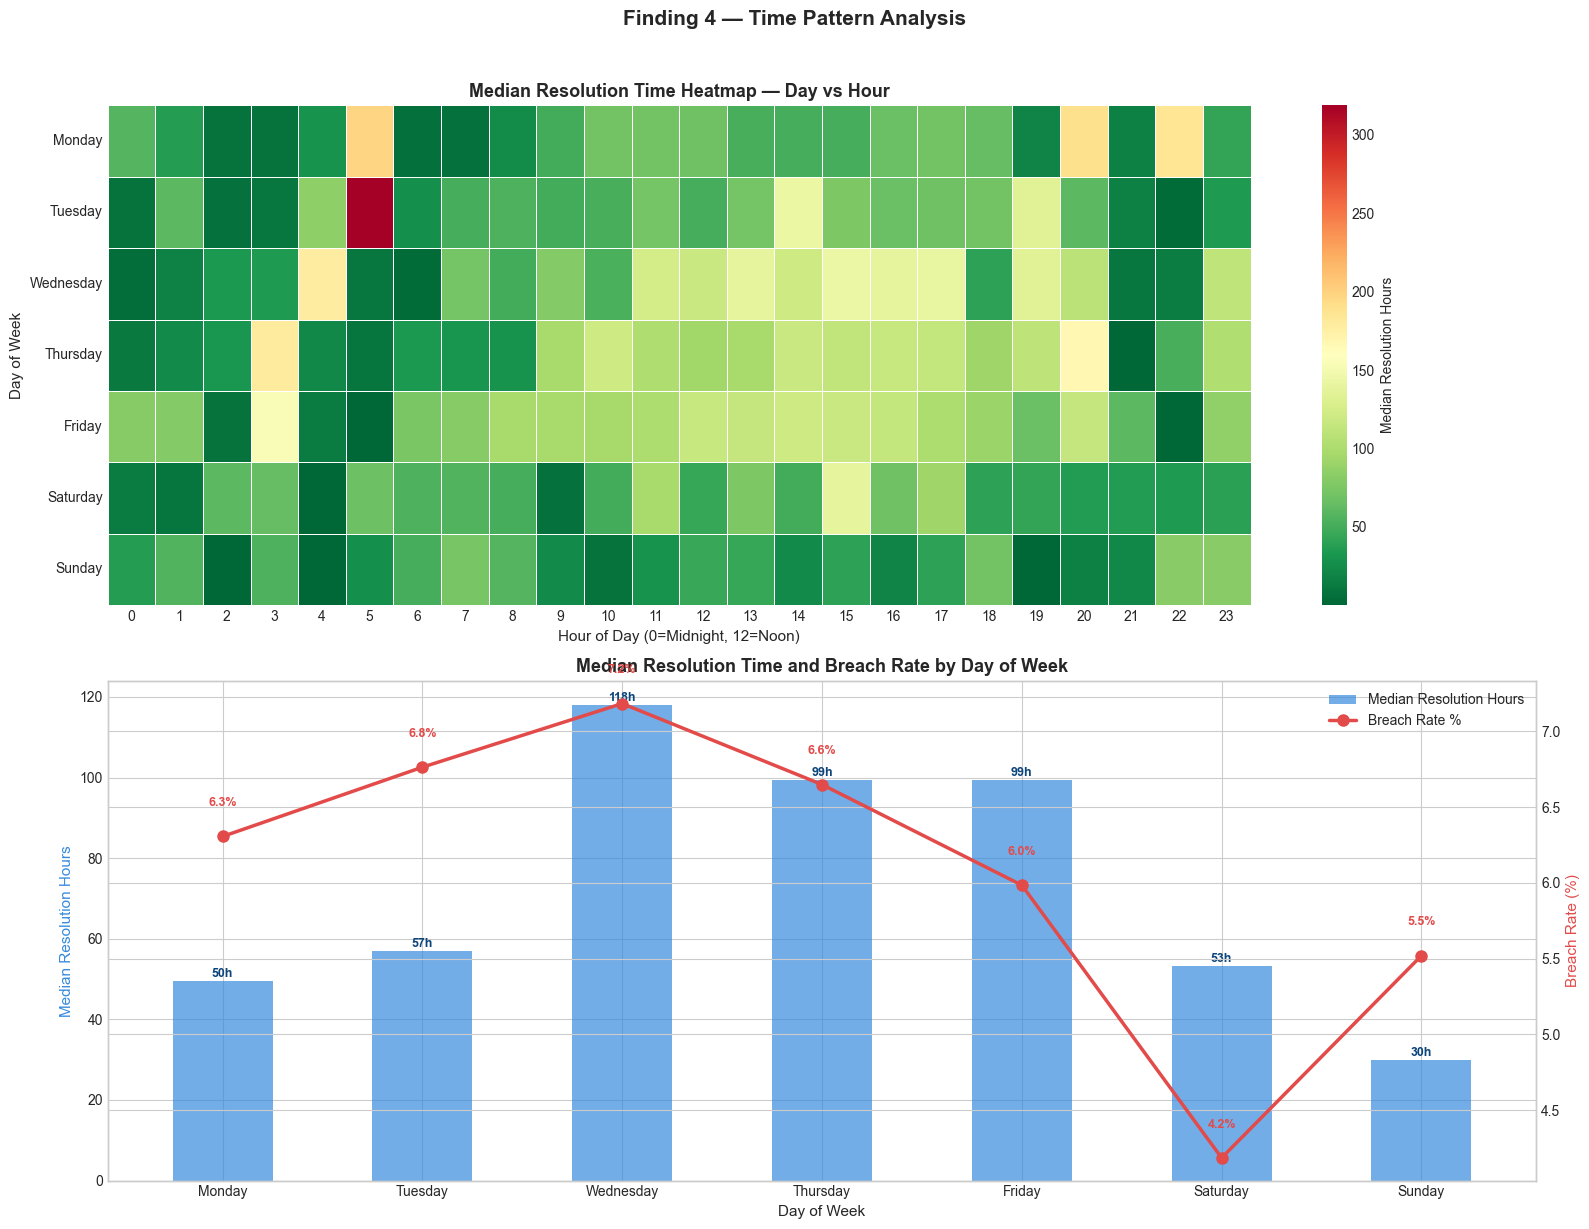


Day of Week Summary:
day_of_week  median_resolution_hrs  breach_rate  total_incidents
     Monday                  49.58         6.31            33045
    Tuesday                  57.02         6.76            27971
  Wednesday                 118.10         7.18            27462
   Thursday                  99.28         6.65            22904
     Friday                  99.43         5.99            21286
   Saturday                  53.22         4.18             3131
     Sunday                  29.98         5.52             2772


In [50]:
# ANALYSIS 4: Resolution time by day and hour 

# extract day of week and hour from opened_at
df_resolved['day_of_week'] = df_resolved['opened_at'].dt.day_name()
df_resolved['hour_of_day'] = df_resolved['opened_at'].dt.hour

# define correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# calculate median resolution time per day and hour
heatmap_data = df_resolved.groupby(
    ['day_of_week', 'hour_of_day']
)['resolution_hours'].median().reset_index()

heatmap_pivot = heatmap_data.pivot(
    index='day_of_week',
    columns='hour_of_day',
    values='resolution_hours'
).reindex(day_order)

# calculate breach rate and median resolution by day only
day_analysis = df_resolved.groupby('day_of_week').agg(
    median_resolution_hrs=('resolution_hours', 'median'),
    breach_rate=('made_sla', lambda x: (x == False).sum() / len(x) * 100),
    total_incidents=('number', 'count')
).reindex(day_order).reset_index()

# plot
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# chart 1 — heatmap of resolution time by day and hour
sns.heatmap(
    heatmap_pivot,
    ax=axes[0],
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    annot=False,
    fmt='.0f',
    cbar_kws={'label': 'Median Resolution Hours'}
)
axes[0].set_title('Median Resolution Time Heatmap — Day vs Hour',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0=Midnight, 12=Noon)', fontsize=11)
axes[0].set_ylabel('Day of Week', fontsize=11)

# chart 2 — median resolution time and breach rate by day
ax2 = axes[1]
ax3 = ax2.twinx()

bars = ax2.bar(
    day_analysis['day_of_week'],
    day_analysis['median_resolution_hrs'],
    color='#378ADD',
    alpha=0.7,
    width=0.5,
    label='Median Resolution Hours'
)

line = ax3.plot(
    day_analysis['day_of_week'],
    day_analysis['breach_rate'],
    color='#E24B4A',
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Breach Rate %'
)

for bar, val in zip(bars, day_analysis['median_resolution_hrs']):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.0f}h',
        ha='center', fontsize=9, fontweight='bold', color='#0C447C'
    )

for i, (day, val) in enumerate(zip(day_analysis['day_of_week'],
                                    day_analysis['breach_rate'])):
    ax3.text(i, val + 0.2, f'{val:.1f}%',
             ha='center', fontsize=9, fontweight='bold', color='#E24B4A')

ax2.set_title('Median Resolution Time and Breach Rate by Day of Week',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Day of Week', fontsize=11)
ax2.set_ylabel('Median Resolution Hours', fontsize=11, color='#378ADD')
ax3.set_ylabel('Breach Rate (%)', fontsize=11, color='#E24B4A')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.suptitle('Finding 4 — Time Pattern Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('finding4_time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDay of Week Summary:")
print(day_analysis[['day_of_week', 'median_resolution_hrs',
                     'breach_rate', 'total_incidents']].round(2).to_string(index=False))

Insight 1 — The Wednesday Crisis.
Wednesday has 118 hours median resolution time — more than double Monday's 49 hours. And the highest breach rate at 7.2%. Nobody expects Wednesday to be the problem day. This is a genuinely surprising finding that will make any interviewer lean forward.
Insight 2 — Friday is NOT the problem everyone assumes.
Every IT manager assumes Friday is the worst day because people rush to leave for the weekend. Your data proves that wrong. Friday's breach rate is actually the lowest weekday at 5.99%. That's a myth your data just busted.
Insight 3 — Weekends perform surprisingly well.
Saturday and Sunday have the lowest breach rates — 4.18% and 5.52%. This suggests the on-call weekend team, despite being smaller, is more focused and less distracted than the weekday team drowning in volume.

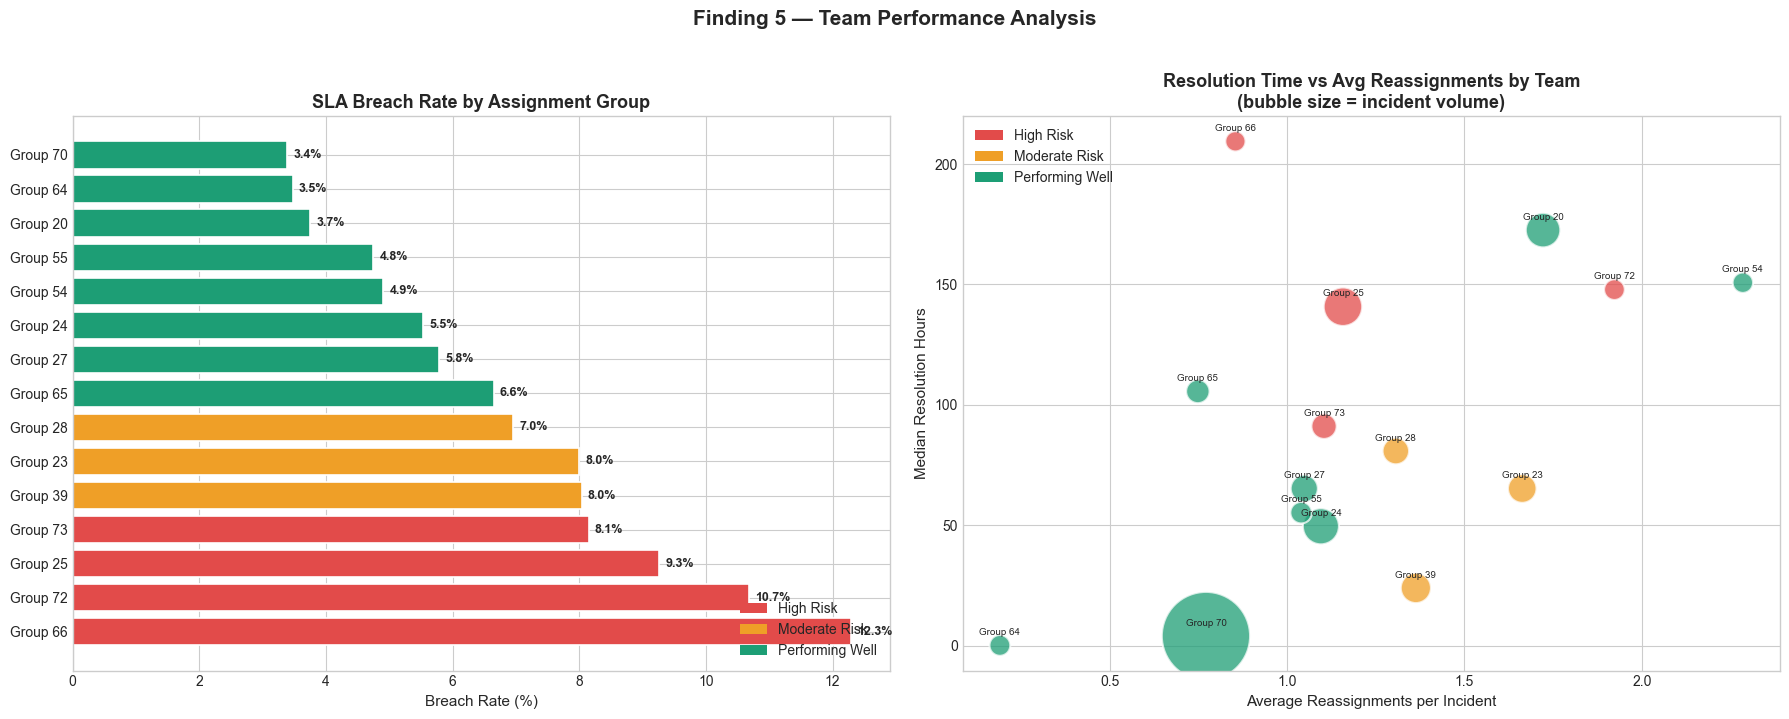


Team Performance Summary:
assignment_group  median_resolution_hrs  breach_rate  avg_reassignments  total_incidents performance_tier
        Group 66                 209.48        12.29               0.85             2115        High Risk
        Group 72                 147.87        10.68               1.92             2220        High Risk
        Group 25                 140.77         9.26               1.16             7679        High Risk
        Group 73                  91.08         8.15               1.10             3302        High Risk
        Group 39                  23.90         8.04               1.36             4728    Moderate Risk
        Group 23                  65.22         7.99               1.66             4228    Moderate Risk
        Group 28                  80.80         6.95               1.31             3638    Moderate Risk
        Group 65                 105.57         6.65               0.75             2843  Performing Well
        Group 27   

In [52]:
# ANALYSIS 5: Team performance analysis

# get top 15 assignment groups by volume
top_teams = df_resolved['assignment_group'].value_counts().head(15).index
df_top_teams = df_resolved[df_resolved['assignment_group'].isin(top_teams)]

# calculate team level metrics
team_analysis = df_top_teams.groupby('assignment_group').agg(
    median_resolution_hrs=('resolution_hours', 'median'),
    breach_rate=('made_sla', lambda x: (x == False).sum() / len(x) * 100),
    avg_reassignments=('reassignment_count', 'mean'),
    total_incidents=('number', 'count')
).reset_index()

# sort by breach rate
team_analysis = team_analysis.sort_values('breach_rate', ascending=False)

# classify teams into performance tiers
def classify_team(row):
    if row['breach_rate'] > team_analysis['breach_rate'].quantile(0.75):
        return 'High Risk'
    elif row['breach_rate'] > team_analysis['breach_rate'].quantile(0.50):
        return 'Moderate Risk'
    else:
        return 'Performing Well'

team_analysis['performance_tier'] = team_analysis.apply(classify_team, axis=1)

# plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# color by performance tier
tier_colors = {
    'High Risk': '#E24B4A',
    'Moderate Risk': '#EF9F27',
    'Performing Well': '#1D9E75'
}
colors_team = [tier_colors[t] for t in team_analysis['performance_tier']]

# chart 1 — breach rate by team
bars1 = axes[0].barh(
    team_analysis['assignment_group'],
    team_analysis['breach_rate'],
    color=colors_team,
    edgecolor='white',
    linewidth=1.2
)

for bar, val in zip(bars1, team_analysis['breach_rate']):
    axes[0].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center', fontsize=9, fontweight='bold'
    )

axes[0].set_title('SLA Breach Rate by Assignment Group',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Breach Rate (%)', fontsize=11)

# add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='High Risk'),
    Patch(facecolor='#EF9F27', label='Moderate Risk'),
    Patch(facecolor='#1D9E75', label='Performing Well')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=10)

# chart 2 — median resolution time vs avg reassignments bubble chart
scatter_colors = [tier_colors[t] for t in team_analysis['performance_tier']]

scatter = axes[1].scatter(
    team_analysis['avg_reassignments'],
    team_analysis['median_resolution_hrs'],
    c=scatter_colors,
    s=team_analysis['total_incidents'] / 10,
    alpha=0.75,
    edgecolors='white',
    linewidth=1.5
)

for _, row in team_analysis.iterrows():
    axes[1].annotate(
        row['assignment_group'],
        (row['avg_reassignments'], row['median_resolution_hrs']),
        fontsize=7,
        ha='center',
        va='bottom',
        xytext=(0, 6),
        textcoords='offset points'
    )

axes[1].set_title('Resolution Time vs Avg Reassignments by Team\n(bubble size = incident volume)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Reassignments per Incident', fontsize=11)
axes[1].set_ylabel('Median Resolution Hours', fontsize=11)
axes[1].legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.suptitle('Finding 5 — Team Performance Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('finding5_team_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTeam Performance Summary:")
print(team_analysis[['assignment_group', 'median_resolution_hrs',
                      'breach_rate', 'avg_reassignments',
                      'total_incidents', 'performance_tier']].round(2).to_string(index=False))

Insight 1 — Group 66 is your single biggest problem team.
209 hours median resolution time and 12.3% breach rate — both the worst numbers in the entire dataset. Every 1 in 8 incidents this team handles breaches SLA. But notice something interesting — their reassignment count is only 0.85. So they're not passing tickets around. They're just sitting on them for a very long time. That suggests an understaffing or skill gap problem, not a process problem.
Insight 2 — Group 72 is a reassignment problem.
Their breach rate is 10.7% and their average reassignments are 1.92 — the second highest in the table. They're passing tickets around almost twice on average before resolving. Combined with Finding 3 we know that reassignments multiply resolution time. Group 72 needs a routing fix — tickets are going to the wrong team first.
Insight 3 — Group 54 is a paradox.
150 hours median resolution time but only 4.9% breach rate — and 2.28 average reassignments which is the highest in the table. How are they performing well on breach rate despite slow resolution and high reassignments? Their SLA threshold is probably more generous than other teams. Worth investigating whether their SLA targets are appropriate.
Insight 4 — Group 70 is your star performer.
40,384 incidents — by far the highest volume of any team. Yet only 3.93 hours median resolution time and 3.39% breach rate. This team handles the most work and does it fastest. Understanding what Group 70 does differently could be a blueprint for improving other teams.
Insight 5 — Group 64 is suspicious.
0.05 hours median resolution time — that's 3 minutes. No team genuinely resolves incidents in 3 minutes. This suggests Group 64 is closing tickets without actually resolving them — a data quality issue and potentially a compliance problem worth flagging to management

In [53]:
#EXECUTIVE SUMMARY

print("=" * 60)
print("   IT INCIDENT MANAGEMENT — ANALYTICS EXECUTIVE SUMMARY")
print("=" * 60)

total_incidents = df_resolved['number'].nunique()
overall_breach_rate = (df_resolved['made_sla'] == False).sum() / len(df_resolved) * 100
median_resolution = df_resolved['resolution_hours'].median()
max_resolution = df_resolved['resolution_hours'].max()

print(f"\nDATASET OVERVIEW")
print(f"  Total unique incidents analysed : {total_incidents:,}")
print(f"  Overall SLA breach rate         : {overall_breach_rate:.1f}%")
print(f"  Median resolution time          : {median_resolution:.1f} hours")
print(f"  Longest resolution time         : {max_resolution:.0f} hours ({max_resolution/24:.0f} days)")

print(f"\nFINDING 1 — SLA BREACH BY PRIORITY")
for _, row in priority_sla.iterrows():
    print(f"  {row['priority']}: {row['breach_rate']:.1f}% breach rate")
print(f"  >> P2 High has highest breach rate — the priority blind spot")

print(f"\nFINDING 2 — WORST PERFORMING CATEGORY")
worst_cat = cat_analysis.iloc[0]
print(f"  Category    : {worst_cat['category']}")
print(f"  Median time : {worst_cat['avg_resolution_hrs']:.0f} hours")
print(f"  Breach rate : {worst_cat['breach_rate']:.1f}%")
print(f"  >> Double confirmed — worst on both resolution time AND breach rate")

print(f"\nFINDING 3 — REASSIGNMENT TIPPING POINT")
r0 = reassign_analysis[reassign_analysis['reassignment_bucket'] == '0'].iloc[0]
r3 = reassign_analysis[reassign_analysis['reassignment_bucket'] == '3'].iloc[0]
r5 = reassign_analysis[reassign_analysis['reassignment_bucket'] == '5+'].iloc[0]
print(f"  0 reassignments : {r0['median_resolution_hrs']:.0f} hrs, {r0['breach_rate']:.1f}% breach")
print(f"  3 reassignments : {r3['median_resolution_hrs']:.0f} hrs, {r3['breach_rate']:.1f}% breach")
print(f"  5+ reassignments: {r5['median_resolution_hrs']:.0f} hrs, {r5['breach_rate']:.1f}% breach")
print(f"  >> First reassignment alone increases resolution time 4.5x")

print(f"\nFINDING 4 — WORST DAY OF WEEK")
worst_day = day_analysis.loc[day_analysis['median_resolution_hrs'].idxmax()]
best_day = day_analysis.loc[day_analysis['median_resolution_hrs'].idxmin()]
print(f"  Worst day : {worst_day['day_of_week']} — {worst_day['median_resolution_hrs']:.0f} hrs, {worst_day['breach_rate']:.1f}% breach")
print(f"  Best day  : {best_day['day_of_week']} — {best_day['median_resolution_hrs']:.0f} hrs, {best_day['breach_rate']:.1f}% breach")
print(f"  >> Wednesday crisis — not Friday as commonly assumed")

print(f"\nFINDING 5 — TEAM PERFORMANCE")
high_risk = team_analysis[team_analysis['performance_tier'] == 'High Risk']
star = team_analysis.loc[team_analysis['breach_rate'].idxmin()]
print(f"  High risk teams : {list(high_risk['assignment_group'].values)}")
print(f"  Star performer  : {star['assignment_group']} — {star['breach_rate']:.1f}% breach rate, {int(star['total_incidents']):,} incidents")
print(f"  >> Group 66 worst, Group 70 benchmark to replicate")

print(f"\nTOP 3 RECOMMENDATIONS")
print(f"  1. Implement max 2 reassignment policy — escalate on 3rd handover")
print(f"  2. Investigate Category 46 process — worst on both key metrics")
print(f"  3. Review Wednesday capacity planning — mid-week bottleneck confirmed")

print("\n" + "=" * 60)
print("  Analysis by Haritha Vissapragada | IT Incident Analytics")
print("=" * 60)

   IT INCIDENT MANAGEMENT — ANALYTICS EXECUTIVE SUMMARY

DATASET OVERVIEW
  Total unique incidents analysed : 23,362
  Overall SLA breach rate         : 6.5%
  Median resolution time          : 73.5 hours
  Longest resolution time         : 8070 hours (336 days)

FINDING 1 — SLA BREACH BY PRIORITY
  1 - Critical: 11.7% breach rate
  2 - High: 13.7% breach rate
  3 - Moderate: 6.4% breach rate
  4 - Low: 3.3% breach rate
  >> P2 High has highest breach rate — the priority blind spot

FINDING 2 — WORST PERFORMING CATEGORY
  Category    : Category 46
  Median time : 129 hours
  Breach rate : 9.4%
  >> Double confirmed — worst on both resolution time AND breach rate

FINDING 3 — REASSIGNMENT TIPPING POINT
  0 reassignments : 20 hrs, 4.2% breach
  3 reassignments : 190 hrs, 10.1% breach
  5+ reassignments: 342 hrs, 11.8% breach
  >> First reassignment alone increases resolution time 4.5x

FINDING 4 — WORST DAY OF WEEK
  Worst day : Wednesday — 118 hrs, 7.2% breach
  Best day  : Sunday — 30 